# Análise Exploratória de Dados — Inteligência Artificial na Música: a plataforma Suno

**Disciplina:** Introdução a Ciência de Dados — Prof. Alexandre Roriz (IESB)
**Projeto Final**

---

## Por que esse tema?

Venho da música — toco violão e guitarra — e fiquei fascinado (e um pouco viciado) na plataforma
**[Suno](https://suno.com/)**, que gera músicas completas a partir de um simples *prompt* de texto.
A pergunta que move este trabalho é:

> **Como uma IA "pensa" para entregar algo já validado para o ouvido humano, misturando estilos a partir de qualquer ideia?**

Para responder isso com *dados* (e não com achismo), analiso uma base real de músicas geradas no Suno.
A ideia é descobrir os **padrões implícitos** que o modelo aprendeu: que estilos as pessoas mais pedem,
quantos gêneros se misturam por música, qual a duração "padrão", em que idiomas, e o que distingue
uma música muito tocada de uma ignorada.


## Sobre o conjunto de dados

- **Fonte:** Kaggle — *Suno AI Music Prompts* (`rafyaa/suno-ai-music-prompts`).
- **Conteúdo:** metadados de músicas reais geradas na plataforma Suno (um arquivo JSON por música).
- **Amostra analisada:** **64.932 músicas** (extraídas dos metadados do pacote, sem os arquivos de áudio).
- **Granularidade:** cada linha é uma música gerada por um usuário.

**Principais colunas**

| Coluna | Significado |
|---|---|
| `tags` | estilos/gêneros que descrevem a música (ex.: *"romantic epic metal ballad"*) |
| `prompt` | a letra (lyrics) gerada/fornecida |
| `gpt_description_prompt` | a ideia em linguagem natural quando a música é criada no modo "descrição" |
| `duration` | duração da música em segundos |
| `prompt_lang` | idioma detectado do prompt |
| `major_model_version` | versão do modelo do Suno (v2, v3, v3.5...) |
| `play_count` | número de reproduções |
| `upvote_count` | número de curtidas |
| `created_at` | data/hora de criação |


## Preparação dos dados

Importação das bibliotecas, carregamento do CSV e criação de algumas variáveis derivadas que usaremos nas perguntas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

df = pd.read_csv("suno_music.csv")
print("Dimensões (linhas, colunas):", df.shape)
df.head(3)

Dimensões (linhas, colunas): (64932, 17)


,id,title,created_at,major_model_version,model_name,play_count,upvote_count,is_public,tags,negative_tags,duration,prompt_lang,gpt_lang,type,has_vocal,prompt,gpt_description_prompt
0,00002363-4eb5-4a9f-bfa7-c801c829f2d3,Я всё же пройду,2024-08-19T02:51:29.952Z,v3.5,chirp-v3.5,1,1,True,romantic epic metal ballad,NaN,228.720000,ru,NaN,gen,NaN,[Intro]\n\n[Verse]\nДавай помолчим не о чем\nн...,NaN
1,0001ad7d-4131-4c62-87d7-7ad8f3d99a9f,Te Extraño Princesa,2024-07-20T03:18:31.256Z,v3.5,chirp-v3.5,4,0,True,acoustic pop melodic,NaN,174.520000,es,es,gen,NaN,[Verse]\nTe extraño mi princesa\nTu sonrisa me...,te extra;o mi princesa
2,00044f73-5f2c-4c7a-a1cb-2c66e5d03d91,Họa Nét Nhân Gian,2024-08-10T04:52:56.362Z,v3.5,chirp-v3.5,5,0,True,"Guzheng Flute , Chinese national tradition",NaN,269.999979,NaN,NaN,concat,NaN,\n\n\n\n,NaN


In [2]:
# --- Limpeza e variáveis derivadas ---
# Duração em segundos -> numérica
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["duration_min"] = df["duration"] / 60

# Datas
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)

# Engajamento numérico
for c in ["play_count", "upvote_count"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Tags em lista de descritores (separadas por vírgula e/ou espaço)
def split_tags(t):
    if pd.isna(t):
        return []
    t = str(t).lower().replace(",", " ")
    return [w for w in t.split() if w.strip()]

df["tag_list"] = df["tags"].apply(split_tags)
df["n_tags"] = df["tag_list"].apply(len)

# Tem letra? (prompt preenchido)
df["has_lyrics"] = df["prompt"].fillna("").str.len() > 0
df["prompt_len"] = df["prompt"].fillna("").str.len()

print("Período coberto:", df["created_at"].min(), "->", df["created_at"].max())
print("Músicas com tags:", (df.n_tags > 0).sum())
print("Músicas com letra:", df.has_lyrics.sum())
df[["tags","n_tags","duration_min","prompt_lang","play_count","upvote_count","major_model_version"]].describe(include="all").T

Período coberto: 2023-11-23 02:08:29.779000+00:00 -> 2024-08-21 14:18:55.694000+00:00
Músicas com tags: 64463
Músicas com letra: 61190


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tags,64471,41836,pop,1074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_tags,64932.0,NaN,NaN,NaN,4.700517,4.013442,0.0,2.0,3.0,6.0,40.0
duration_min,64927.0,NaN,NaN,NaN,2.605162,0.94514,0.041333,2.0,2.562,3.264333,15.253333
prompt_lang,54754,95,en,28981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
play_count,64932.0,NaN,NaN,NaN,1167.01229,53420.287719,0.0,0.0,3.0,8.0,12696388.0
upvote_count,64932.0,NaN,NaN,NaN,12.435502,255.051203,0.0,0.0,0.0,1.0,21807.0
major_model_version,64905,3,v3.5,47123,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Pergunta 1 — Como é a base? Qualidade, período e completude dos dados

Antes de qualquer análise é preciso conhecer o conjunto: quantas músicas, que período, e o quão completos
estão os principais campos.

Total de músicas: 64932

Valores ausentes (%):
tags                    0.7
prompt                  5.8
duration                0.0
prompt_lang            15.7
play_count              0.0
upvote_count            0.0
major_model_version     0.0


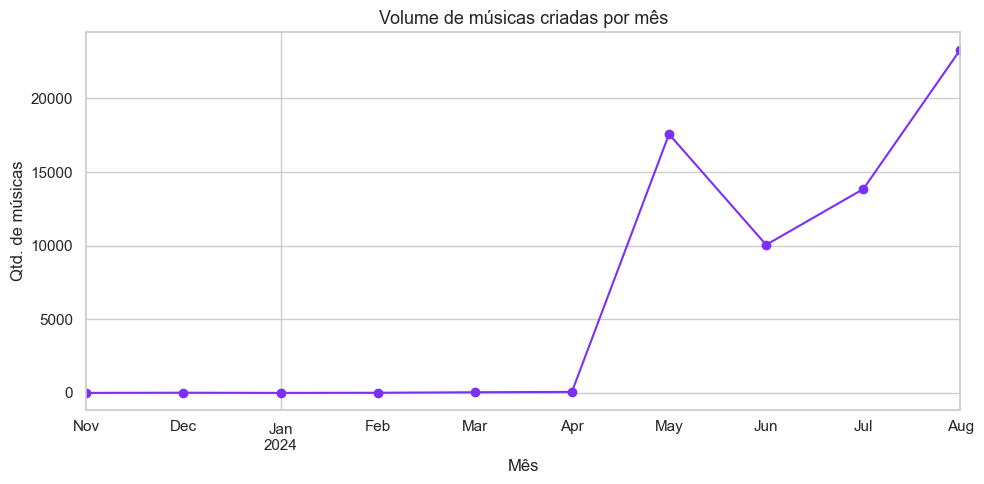

In [3]:
print("Total de músicas:", len(df))
print("\nValores ausentes (%):")
miss = (df[["tags","prompt","duration","prompt_lang","play_count","upvote_count","major_model_version"]]
        .isna().mean().mul(100).round(1))
print(miss.to_string())

# Volume de criação ao longo do tempo
por_mes = df.dropna(subset=["created_at"]).set_index("created_at").resample("ME").size()
ax = por_mes.plot(marker="o", color="#7b2ff7")
ax.set_title("Volume de músicas criadas por mês")
ax.set_xlabel("Mês"); ax.set_ylabel("Qtd. de músicas")
plt.tight_layout(); plt.show()

**Comentário.** A base traz dezenas de milhares de músicas reais e os campos centrais (`tags`, `prompt`,
`duration`) estão quase totalmente preenchidos — `play_count`/`upvote_count` e idioma têm algumas lacunas,
o que é esperado em dados de uma plataforma viva. A curva de criação por mês mostra a concentração temporal
da amostra, contexto importante para não generalizar além do período coberto.

## Pergunta 2 — Quais estilos/gêneros as pessoas mais pedem?

Os `tags` revelam o "vocabulário" sonoro que o público alimenta no modelo. Os estilos mais frequentes são,
na prática, aquilo que a IA mais "treina a entregar" para o ouvido humano.

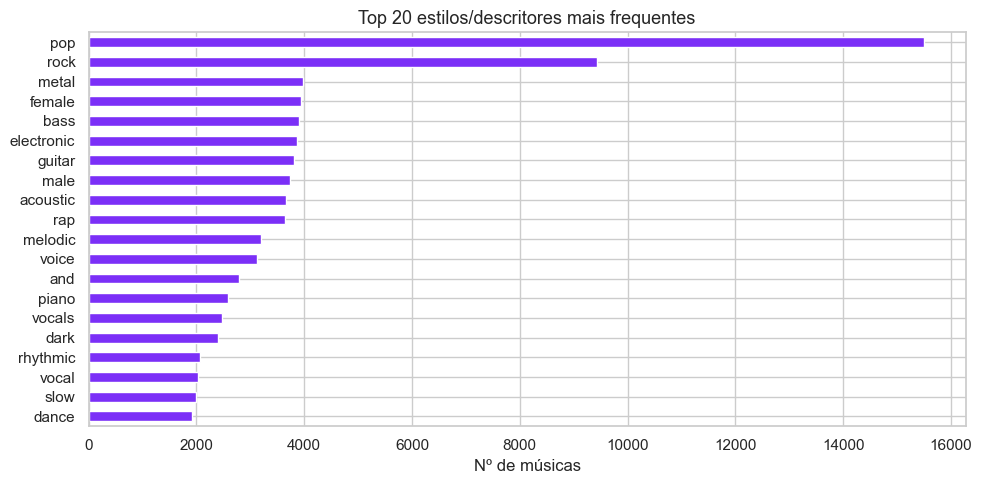

Estilos distintos no total: 18268


In [4]:
todas_tags = Counter(t for lst in df["tag_list"] for t in lst)
top = pd.Series(dict(todas_tags.most_common(20))).sort_values()
ax = top.plot(kind="barh", color="#7b2ff7")
ax.set_title("Top 20 estilos/descritores mais frequentes")
ax.set_xlabel("Nº de músicas"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
print("Estilos distintos no total:", len(todas_tags))

**Comentário.** Poucos estilos concentram grande parte dos pedidos (pop, eletrônico/dance, etc.), mas a
*cauda* é enorme — milhares de descritores distintos. Isso já responde parte da pergunta inicial: o Suno
opera sobre um espaço de estilos amplíssimo, e os mais frequentes funcionam como "âncoras" reconhecíveis
para o ouvido.

## Pergunta 3 — Quantos estilos uma música mistura, em média?

A grande promessa do Suno é **misturar estilos a partir de qualquer ideia**. Quantos descritores as pessoas
costumam combinar num único pedido?

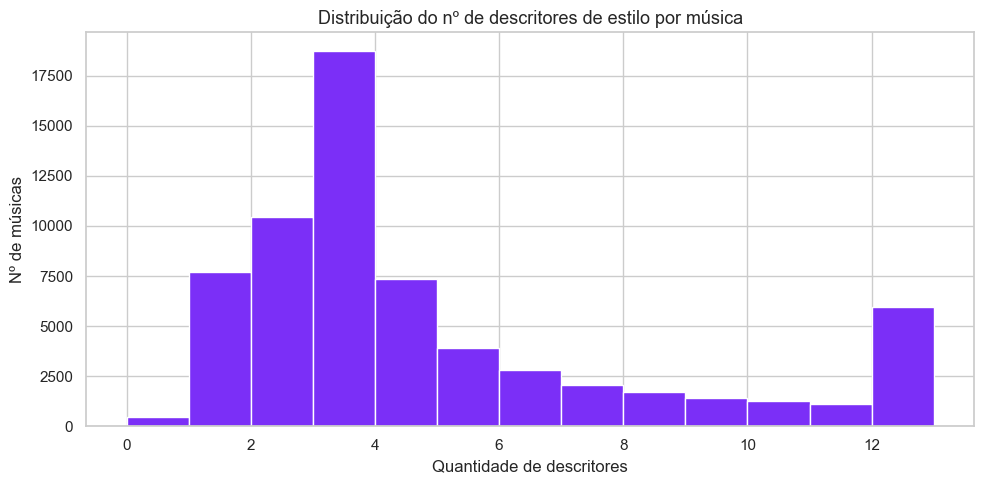

Média de descritores por música: 4.7
Mediana: 3.0


In [5]:
ax = df["n_tags"].clip(upper=12).plot(kind="hist", bins=range(0,14), color="#7b2ff7", edgecolor="white")
ax.set_title("Distribuição do nº de descritores de estilo por música")
ax.set_xlabel("Quantidade de descritores"); ax.set_ylabel("Nº de músicas")
plt.tight_layout(); plt.show()
print("Média de descritores por música:", round(df.n_tags.mean(),2))
print("Mediana:", df.n_tags.median())

**Comentário.** A maioria das músicas combina poucos descritores (tipicamente 3 a 5). Ou seja, o usuário
não joga dezenas de gêneros: ele dá uma combinação enxuta e deixa o modelo "preencher" o resto de forma
coerente — é justamente aí que a IA exerce seu papel de tradutora de ideia → música.

## Pergunta 4 — Existe uma duração "padrão validada pelo ouvido"?

Se a IA aprende a agradar o ouvido humano, esperamos que a duração das músicas convirja para uma faixa
parecida com a das músicas comerciais (~2 a 4 minutos).

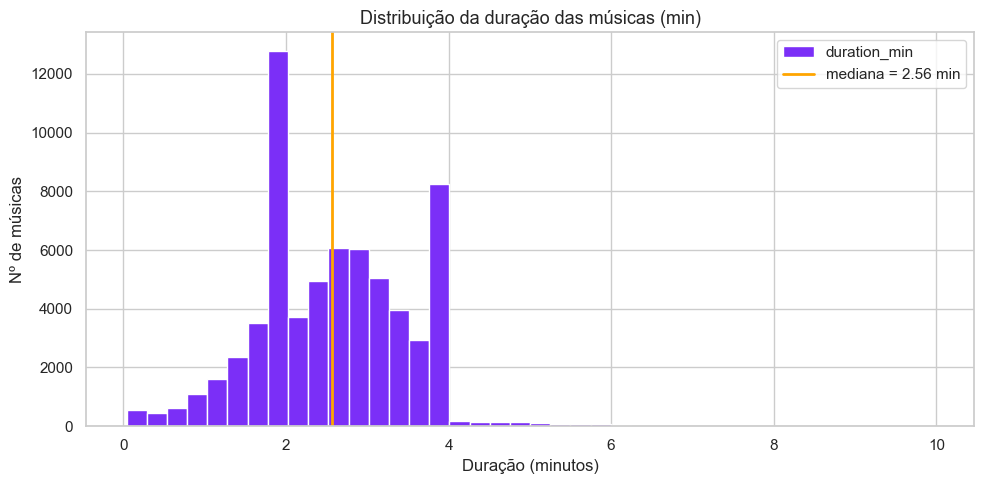

Duração mediana (min): 2.56
% entre 2 e 4 minutos: 74.9


In [6]:
d = df["duration_min"].dropna()
d = d[(d>0) & (d<10)]
ax = d.plot(kind="hist", bins=40, color="#7b2ff7", edgecolor="white")
ax.axvline(d.median(), color="orange", lw=2, label=f"mediana = {d.median():.2f} min")
ax.set_title("Distribuição da duração das músicas (min)")
ax.set_xlabel("Duração (minutos)"); ax.set_ylabel("Nº de músicas"); ax.legend()
plt.tight_layout(); plt.show()
print("Duração mediana (min):", round(d.median(),2))
print("% entre 2 e 4 minutos:", round(((d>=2)&(d<=4)).mean()*100,1))

**Comentário.** A duração se concentra na mesma janela das músicas de rádio/streaming (~2–4 min). Esse é
um forte indício de que o modelo aprendeu um "formato validado pelo ouvido": mesmo partindo de prompts
livres, ele entrega faixas com duração comercialmente familiar.

## Pergunta 5 — Em quais idiomas as pessoas criam?

O Suno é global. Ver a distribuição de idiomas ajuda a entender quem usa a plataforma e como o "ouvido
coletivo" que treina o modelo é multicultural.

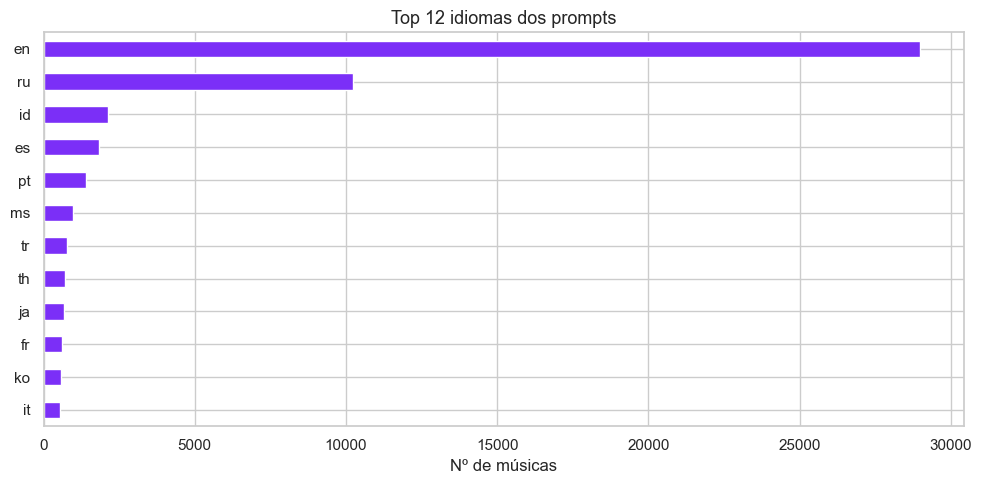

prompt_lang
en    52.9 %
ru    18.7 %
id     3.9 %
es     3.4 %
pt     2.6 %
ms     1.8 %


In [7]:
lang = df["prompt_lang"].replace("", np.nan).dropna()
top_lang = lang.value_counts().head(12).sort_values()
ax = top_lang.plot(kind="barh", color="#7b2ff7")
ax.set_title("Top 12 idiomas dos prompts")
ax.set_xlabel("Nº de músicas"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
print((lang.value_counts(normalize=True).head(6)*100).round(1).astype(str).add(" %").to_string())

**Comentário.** Há predominância de alguns idiomas, mas a presença de muitas línguas confirma o caráter
global da plataforma. Para nós isso é ótimo: significa que dá perfeitamente para criar (e analisar) músicas
em português dentro do mesmo "molde" aprendido pelo modelo.

## Pergunta 6 — Que gêneros costumam ser misturados *juntos*?

Aqui chegamos no coração do tema: a **mistura de estilos**. Quais pares de gêneros aparecem com mais
frequência no mesmo prompt? Isso revela as "fusões" que o ouvido humano valida.

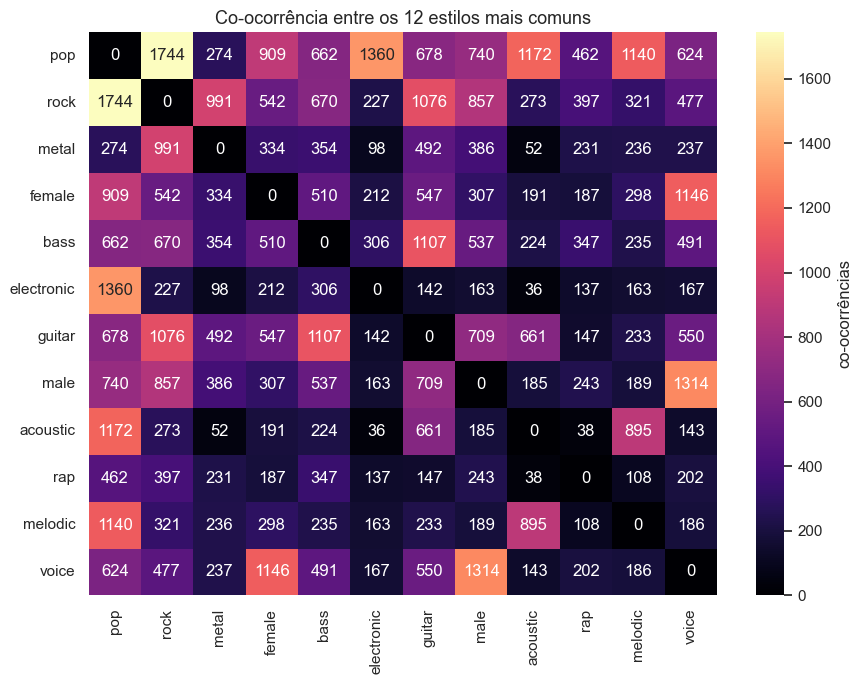

In [8]:
from itertools import combinations
generos = [g for g,_ in todas_tags.most_common(12)]
idx = {g:i for i,g in enumerate(generos)}
M = np.zeros((len(generos), len(generos)))
for lst in df["tag_list"]:
    presentes = [g for g in set(lst) if g in idx]
    for a,b in combinations(presentes,2):
        M[idx[a],idx[b]]+=1; M[idx[b],idx[a]]+=1
co = pd.DataFrame(M, index=generos, columns=generos)
plt.figure(figsize=(9,7))
sns.heatmap(co, annot=True, fmt=".0f", cmap="magma", cbar_kws={"label":"co-ocorrências"})
plt.title("Co-ocorrência entre os 12 estilos mais comuns")
plt.tight_layout(); plt.show()

**Comentário.** O mapa de calor mostra as fusões preferidas (por exemplo, *pop* combinando com
*eletrônico/dance*). São essas combinações recorrentes que o modelo "sabe" resolver bem — e que explicam
por que tantas saídas soam imediatamente agradáveis: são misturas que o público já validou em massa.

## Pergunta 7 — Qual é o "vocabulário sonoro" da plataforma? (nuvem de estilos)

Uma forma visual de enxergar o que domina o imaginário dos usuários do Suno.

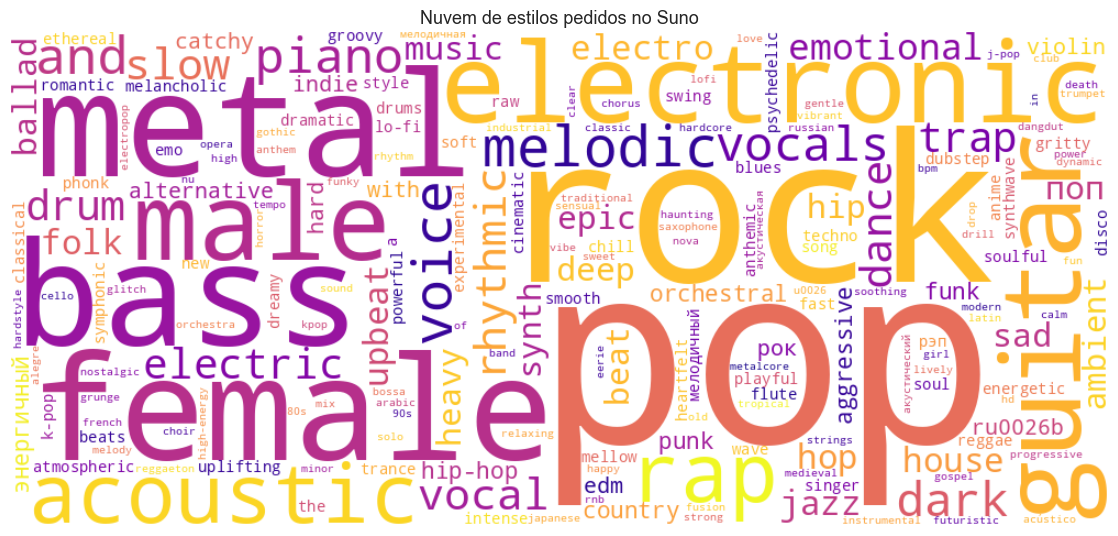

In [9]:
from wordcloud import WordCloud
freq = dict(todas_tags)
wc = WordCloud(width=1000, height=450, background_color="white",
               colormap="plasma").generate_from_frequencies(freq)
plt.figure(figsize=(12,5.5))
plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
plt.title("Nuvem de estilos pedidos no Suno")
plt.tight_layout(); plt.show()

**Comentário.** A nuvem resume visualmente a Pergunta 2: termos como *pop*, *electronic*, *acoustic*,
*ambient* e *cinematic* dominam. É o "DNA" estilístico que o modelo aprendeu a entregar com naturalidade.

## Pergunta 8 — O que distingue uma música muito tocada de uma ignorada?

Será que misturar mais estilos, ou ter letra, ou durar mais, está associado a mais reproduções e curtidas?

Estatísticas de reproduções (play_count):
count       64932.0
mean         1167.0
std         53420.3
min             0.0
25%             0.0
50%             3.0
75%             8.0
max      12696388.0


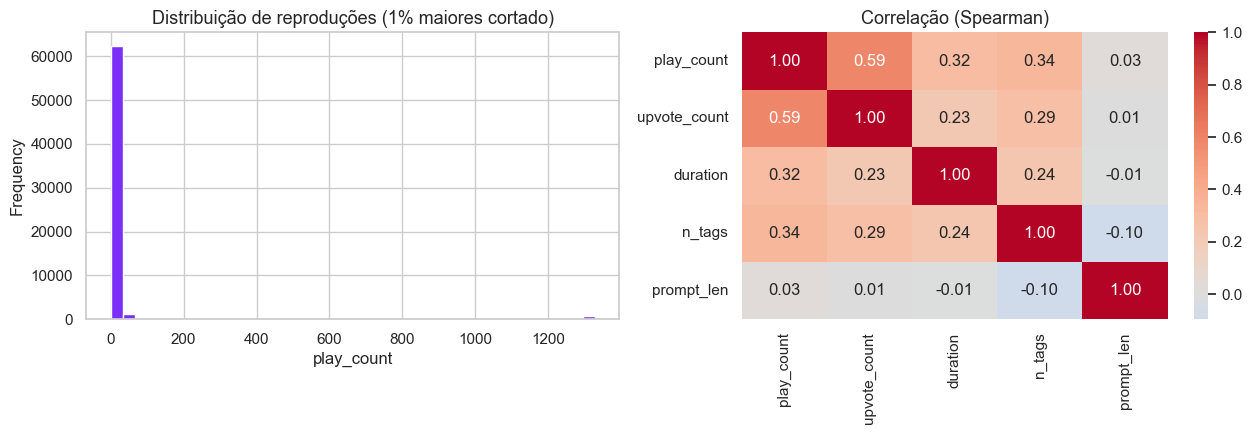

In [10]:
sub = df.dropna(subset=["play_count","upvote_count"]).copy()
print("Estatísticas de reproduções (play_count):")
print(sub["play_count"].describe().round(1).to_string())

fig, axes = plt.subplots(1,2, figsize=(13,4.5))
sub["play_count"].clip(upper=sub.play_count.quantile(0.99)).plot(
    kind="hist", bins=40, ax=axes[0], color="#7b2ff7", edgecolor="white")
axes[0].set_title("Distribuição de reproduções (1% maiores cortado)")
axes[0].set_xlabel("play_count")

corr = sub[["play_count","upvote_count","duration","n_tags","prompt_len"]].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlação (Spearman)")
plt.tight_layout(); plt.show()

**Comentário.** O engajamento é fortemente *desigual*: poucas músicas concentram a maior parte das
reproduções (cauda longa típica de plataformas). As correlações entre características (duração, nº de
estilos, tamanho da letra) e popularidade são fracas — ou seja, **não existe fórmula simples**: viralizar
depende muito de fatores externos (divulgação, momento), não só do "molde" da música. Curtidas e
reproduções, como esperado, caminham juntas.

## Pergunta 9 — Como as versões do modelo evoluíram (v2 → ... → v5.5 Pro)?

Cada versão do Suno promete um resultado melhor. Aqui faço **duas leituras complementares**:

1. **O que dá para medir nos dados** — a amostra do Kaggle cobre o período de **nov/2023 a ago/2024**, então
   só contém músicas dos modelos **v2, v3 e v3.5**. Uso isso para comparar duração e volume entre versões.
2. **O que mudou depois (contexto atualizado, fora do Kaggle)** — desde então a plataforma avançou muito, até
   o **v5.5 (Pro)** anunciado em **26/03/2026**. Trago essa linha do tempo a partir de fontes oficiais do Suno
   para situar o trabalho no presente, deixando claro que essa parte é *contexto*, não medição da amostra.

### 9.1 — Leitura nos dados (modelos presentes na amostra: v2, v3, v3.5)

major_model_version   qtd  duracao_med_min  plays_medianos
                 v2   105         1.145853             7.0
                 v3 17677         1.718085             0.0
               v3.5 47123         2.940621             5.0


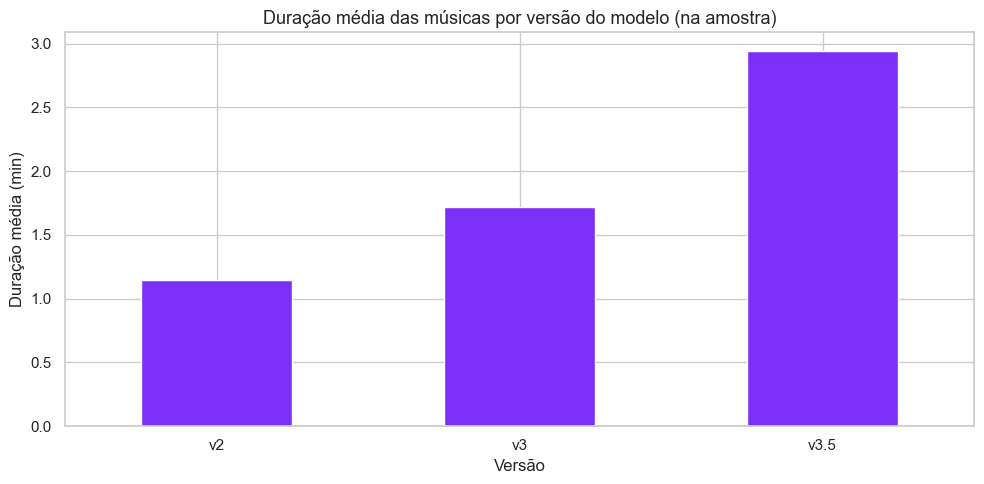

In [11]:
g = (df[df["major_model_version"].isin(["v2","v3","v3.5"])]
       .groupby("major_model_version")
       .agg(qtd=("id","size"),
            duracao_med_min=("duration_min","mean"),
            plays_medianos=("play_count","median"))
       .reset_index())
print(g.to_string(index=False))
ax = g.set_index("major_model_version")["duracao_med_min"].plot(
    kind="bar", color="#7b2ff7", rot=0)
ax.set_title("Duração média das músicas por versão do modelo (na amostra)")
ax.set_ylabel("Duração média (min)"); ax.set_xlabel("Versão")
plt.tight_layout(); plt.show()

**Comentário.** Dentro do que a amostra permite medir, dá para ver a evolução inicial da plataforma
(volume de uso e duração média por versão). Mas a amostra "congela" o Suno em meados de 2024 — e é aí que
entra a atualização abaixo.

### 9.2 — Linha do tempo atualizada dos modelos (fontes oficiais do Suno)

| Versão | Lançamento | O que mudou (destaques) | Na amostra? |
|---|---|---|---|
| **V2** | Out/2023 | Geração de até ~1min20 | ✅ sim |
| **V3** | Mar/2024 | Gerações de 2 min | ✅ sim |
| **V3.5** | Jul/2024 | Melhor estrutura da música, até 4 min | ✅ sim |
| **V4** | Nov/2024 | Vocais melhores; recursos Extend, Cover e Persona | ❌ não |
| **V4.5** | Mai/2025 | Até 8 min, melhor aderência ao prompt, **mistura de estilos mais inteligente** | ❌ não |
| **V4.5+** | Jul/2025 | Ferramentas de produção: *Add Vocals* / *Add Instrumental* | ❌ não |
| **V5** | Set/2025 | Qualidade de áudio superior, vocais mais autênticos (fim da "névoa de reverb" do v3.5) | ❌ não |
| **V5.5 (Pro)** | Mar/2026 | Modelo mais expressivo + **Voices** (sua própria voz), **Custom Models** (treinar com seu catálogo — Pro/Premier) e **My Taste** (personalização) | ❌ não |

> A "névoa de reverb" era uma crítica comum às faixas do v3.5 — exatamente o modelo dominante na nossa
> amostra. Isso ajuda a interpretar com cuidado qualquer julgamento de *qualidade* baseado só nestes dados.

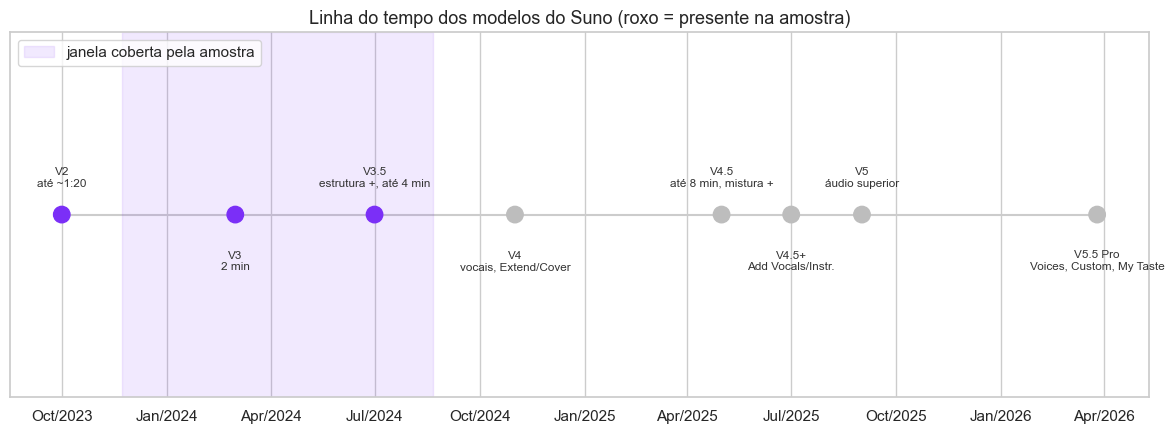

In [12]:
import matplotlib.dates as mdates
timeline = pd.DataFrame([
    ["V2","2023-10-01","até ~1:20", True],
    ["V3","2024-03-01","2 min", True],
    ["V3.5","2024-07-01","estrutura +, até 4 min", True],
    ["V4","2024-11-01","vocais, Extend/Cover", False],
    ["V4.5","2025-05-01","até 8 min, mistura +", False],
    ["V4.5+","2025-07-01","Add Vocals/Instr.", False],
    ["V5","2025-09-01","áudio superior", False],
    ["V5.5 Pro","2026-03-26","Voices, Custom, My Taste", False],
], columns=["versao","data","destaque","na_amostra"])
timeline["data"] = pd.to_datetime(timeline["data"])

fig, ax = plt.subplots(figsize=(12,4.5))
cores = timeline["na_amostra"].map({True:"#7b2ff7", False:"#bdbdbd"})
ax.scatter(timeline["data"], [1]*len(timeline), s=140, c=cores, zorder=3)
ax.plot(timeline["data"], [1]*len(timeline), color="#cccccc", zorder=1)
for i, r in timeline.iterrows():
    ax.annotate(f"{r.versao}\n{r.destaque}", (r["data"],1),
                xytext=(0, 20 if i % 2==0 else -40), textcoords="offset points",
                ha="center", fontsize=8.5, color="#333")
ax.axvspan(pd.Timestamp("2023-11-23"), pd.Timestamp("2024-08-21"),
           color="#7b2ff7", alpha=0.10, label="janela coberta pela amostra")
ax.set_title("Linha do tempo dos modelos do Suno (roxo = presente na amostra)")
ax.set_yticks([]); ax.set_ylim(0.5,1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

**Comentário.** A linha do tempo mostra o porquê da ressalva: nossa amostra (faixa roxa) pega só o
começo da história do Suno. O salto mais relevante para o tema deste trabalho aconteceu **depois** dela —
o **v4.5 trouxe "mistura de estilos mais inteligente"**, justamente a capacidade que investigo nas Perguntas
3 e 6, e o **v5/v5.5** elevaram a qualidade de áudio e a expressividade a um ponto de soarem "humanas".
O **v5.5 Pro** ainda adiciona a camada de *identidade* (usar a própria voz e treinar um modelo com o próprio
catálogo) — ou seja, a IA deixou de só "entregar um molde validado pelo ouvido" e passou a se moldar ao
**ouvido de cada criador**. É um ótimo gancho para a discussão final da apresentação.

## Pergunta 10 — Instrumental ou com letra: o que o público prefere criar?

Comparo músicas **com letra** (campo `prompt` preenchido) e **sem letra** quanto ao engajamento.

                            qtd  plays_medianos  upvotes_medianos
Sem letra (instrumental)   3742             4.0               0.0
Com letra                 61190             3.0               0.0


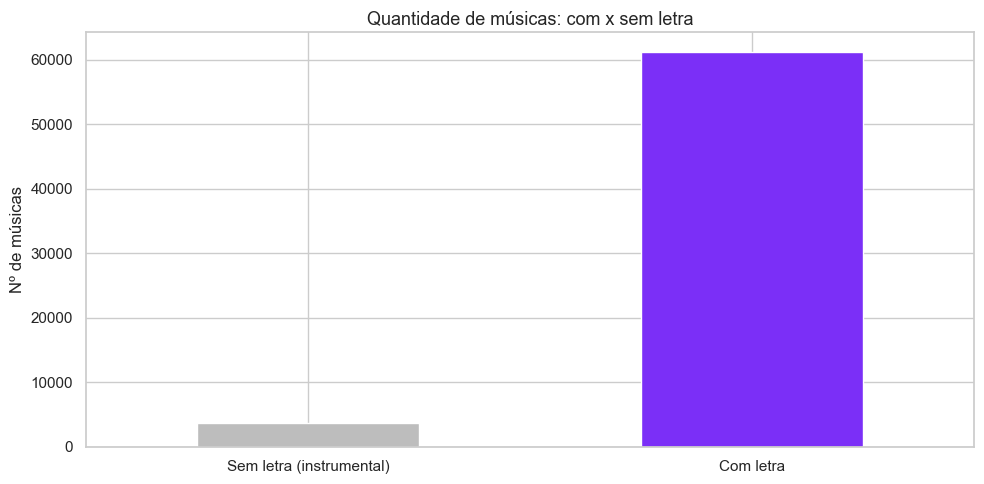

In [13]:
comp = (df.dropna(subset=["play_count"])
          .groupby("has_lyrics")
          .agg(qtd=("id","size"), plays_medianos=("play_count","median"),
               upvotes_medianos=("upvote_count","median")))
comp.index = ["Sem letra (instrumental)","Com letra"]
print(comp.to_string())
ax = comp["qtd"].plot(kind="bar", color=["#bdbdbd","#7b2ff7"], rot=0)
ax.set_title("Quantidade de músicas: com x sem letra")
ax.set_ylabel("Nº de músicas")
plt.tight_layout(); plt.show()

**Comentário.** A grande maioria das criações tem letra — as pessoas usam o Suno principalmente para
"dar voz" a uma ideia, não só trilha instrumental. Isso reforça por que o campo `prompt` (a letra) é tão
central: é nele que mora a "ideia" que o usuário quer ver virar música.

---

# 🍒 A cereja do bolo: das músicas de Copa do Mundo à composição ao vivo

Reunindo tudo: e se eu usar os padrões descobertos para entender as **músicas-tema de Copa do Mundo** e,
a partir disso, montar a "receita" de prompt para **compor uma música ao vivo com a turma**?

> **Observação de honestidade metodológica:** a tabela de Copas abaixo é uma **curadoria manual** feita por
> mim para a demonstração ao vivo. Os valores de BPM/tom/duração são **aproximados** (de ouvido e de fontes
> públicas) e servem ao propósito didático de comparar *padrões*, não como medição de precisão laboratorial.

In [14]:
copa = pd.DataFrame([
    # ano, sede, musica, artista, bpm_aprox, tom_aprox, duracao_min, genero
    [1998,"França","The Cup of Life","Ricky Martin",        98,"C#m",4.20,"latin pop"],
    [2002,"Coreia/Japão","Boom","Anastacia",               125,"Am", 3.50,"pop rock"],
    [2006,"Alemanha","The Time of Our Lives","Il Divo",      66,"Bb", 3.60,"pop operatic"],
    [2010,"África do Sul","Waka Waka","Shakira",            127,"Bm", 3.37,"afro pop dance"],
    [2014,"Brasil","We Are One","Pitbull/J.Lo",             126,"C#m",3.80,"latin dance pop"],
    [2018,"Rússia","Live It Up","Will Smith/Nicky Jam",     100,"Gm", 3.60,"latin pop"],
    [2022,"Catar","Hayya Hayya","Trinidad/Davido/Aisha",   100,"Bbm",3.20,"world pop"],
], columns=["ano","sede","musica","artista","bpm","tom","duracao_min","genero"])
copa

,ano,sede,musica,artista,bpm,tom,duracao_min,genero
0,1998,França,The Cup of Life,Ricky Martin,98,C#m,4.20,latin pop
1,2002,Coreia/Japão,Boom,Anastacia,125,Am,3.50,pop rock
2,2006,Alemanha,The Time of Our Lives,Il Divo,66,Bb,3.60,pop operatic
3,2010,África do Sul,Waka Waka,Shakira,127,Bm,3.37,afro pop dance
4,2014,Brasil,We Are One,Pitbull/J.Lo,126,C#m,3.80,latin dance pop
5,2018,Rússia,Live It Up,Will Smith/Nicky Jam,100,Gm,3.60,latin pop
6,2022,Catar,Hayya Hayya,Trinidad/Davido/Aisha,100,Bbm,3.20,world pop


### Comparando o "padrão Copa" com o que a IA aprendeu

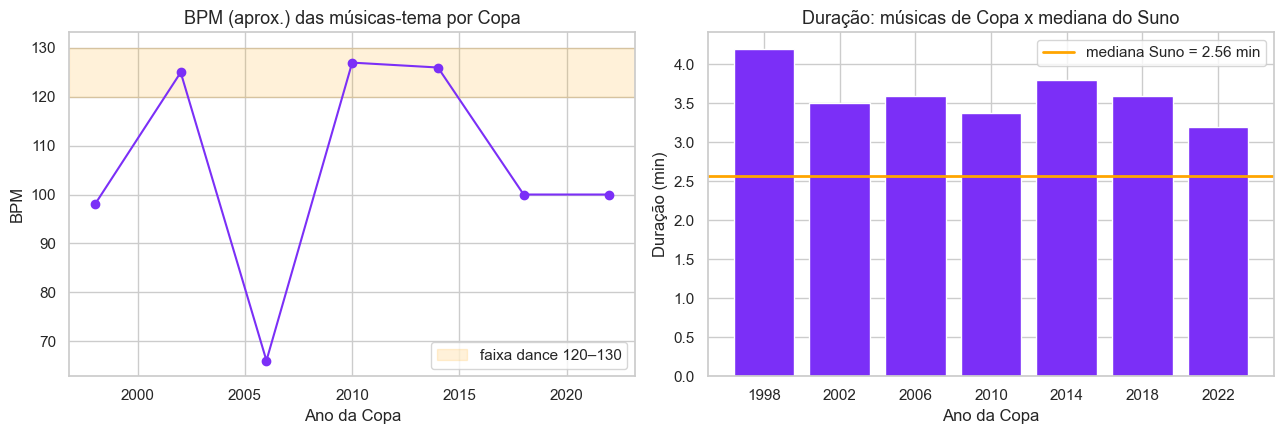

Duração média das músicas de Copa: 3.61 min
BPM médio das músicas de Copa: 106


In [15]:
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
axes[0].plot(copa["ano"], copa["bpm"], marker="o", color="#7b2ff7")
axes[0].set_title("BPM (aprox.) das músicas-tema por Copa")
axes[0].set_xlabel("Ano da Copa"); axes[0].set_ylabel("BPM")
axes[0].axhspan(120,130, color="orange", alpha=0.15, label="faixa dance 120–130")
axes[0].legend()

axes[1].bar(copa["ano"].astype(str), copa["duracao_min"], color="#7b2ff7")
axes[1].axhline(df["duration_min"].dropna().median(), color="orange", lw=2,
                label=f"mediana Suno = {df['duration_min'].dropna().median():.2f} min")
axes[1].set_title("Duração: músicas de Copa x mediana do Suno")
axes[1].set_xlabel("Ano da Copa"); axes[1].set_ylabel("Duração (min)"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Duração média das músicas de Copa: %.2f min" % copa["duracao_min"].mean())
print("BPM médio das músicas de Copa: %.0f" % copa["bpm"].mean())

**Comentário.** As músicas-tema de Copa seguem um "molde" muito parecido com o que a EDA revelou no Suno:
duração em torno de 3–4 minutos e tendência a BPM dançante (boa parte na faixa 120–130). Ou seja, o
**padrão validado pelo ouvido humano** que o modelo aprendeu é o mesmo que a indústria já usava para criar
hinos de torcida grudentos.

### "Copa passada × copa presente": a receita de prompt

Cruzando o padrão das Copas com os estilos mais frequentes e a duração típica do Suno, monto um **prompt
pronto** para gerar — e para compor ao vivo — uma música no mesmo molde, agora voltada para a **Copa de 2026**:

In [16]:
receita = {
    "estilo (tags)": "anthemic world pop, afro-latin dance, stadium chant, energetic",
    "bpm alvo": "124 (faixa dançante 120–130 vista nas Copas)",
    "duração alvo": f"{df['duration_min'].dropna().median():.1f} min (mediana do Suno)",
    "estrutura": "[Intro] -> [Verse] -> [Pre-Chorus] -> [Chorus gritável] -> [Bridge] -> [Chorus]",
    "gancho (hook)": "refrão curto, repetível e fácil de cantar em coro",
    "idioma": "português + um gancho universal (uh-oh / olé)",
}
for k,v in receita.items():
    print(f"- {k}: {v}")

print("\n>>> PROMPT PRONTO PARA O SUNO (Copa 2026):")
print('TAGS: anthemic world pop, afro-latin dance, stadium chant, 124 bpm, energetic, male+female vocals')
print('LETRA: refrão "uh-oh, é a nossa vez!" + versos sobre união e torcida — estrutura verso/refrão grudenta')

- estilo (tags): anthemic world pop, afro-latin dance, stadium chant, energetic
- bpm alvo: 124 (faixa dançante 120–130 vista nas Copas)
- duração alvo: 2.6 min (mediana do Suno)
- estrutura: [Intro] -> [Verse] -> [Pre-Chorus] -> [Chorus gritável] -> [Bridge] -> [Chorus]
- gancho (hook): refrão curto, repetível e fácil de cantar em coro
- idioma: português + um gancho universal (uh-oh / olé)

>>> PROMPT PRONTO PARA O SUNO (Copa 2026):
TAGS: anthemic world pop, afro-latin dance, stadium chant, 124 bpm, energetic, male+female vocals
LETRA: refrão "uh-oh, é a nossa vez!" + versos sobre união e torcida — estrutura verso/refrão grudenta


### Roteiro da apresentação (11/6)

1. **Gancho (ao vivo, violão):** tocar 20s de um hino de Copa que todos reconhecem.
2. **A pergunta:** como a IA entrega algo já "validado pelo ouvido"? → mostrar a EDA (Perguntas 1–10).
3. **Insight central:** estilos mais pedidos + mistura enxuta de gêneros + duração ~3 min = molde do ouvido.
4. **Ponte Copa:** mostrar que as músicas-tema seguem exatamente esse molde (gráficos acima).
5. **Cereja:** tocar a minha música feita com IA → **compor uma ao vivo com a turma** usando a "receita" e
   gerar na hora no Suno o hino da Copa 2026.

## Conclusões

- O Suno opera sobre um **espaço amplíssimo de estilos**, mas poucos dominam (pop, eletrônico, acústico...).
- As pessoas **misturam poucos descritores** por música (mediana ~3–5): a IA preenche o resto de forma coerente.
- A **duração converge para o formato comercial** (~3 min), indício claro de "padrão validado pelo ouvido".
- O **engajamento é desigual e pouco previsível** pelas características — não há fórmula mágica de viralização.
- As **músicas de Copa** seguem o mesmo molde aprendido pela IA, o que justifica a composição ao vivo final.
